# Elasticsearch 설치 확인  

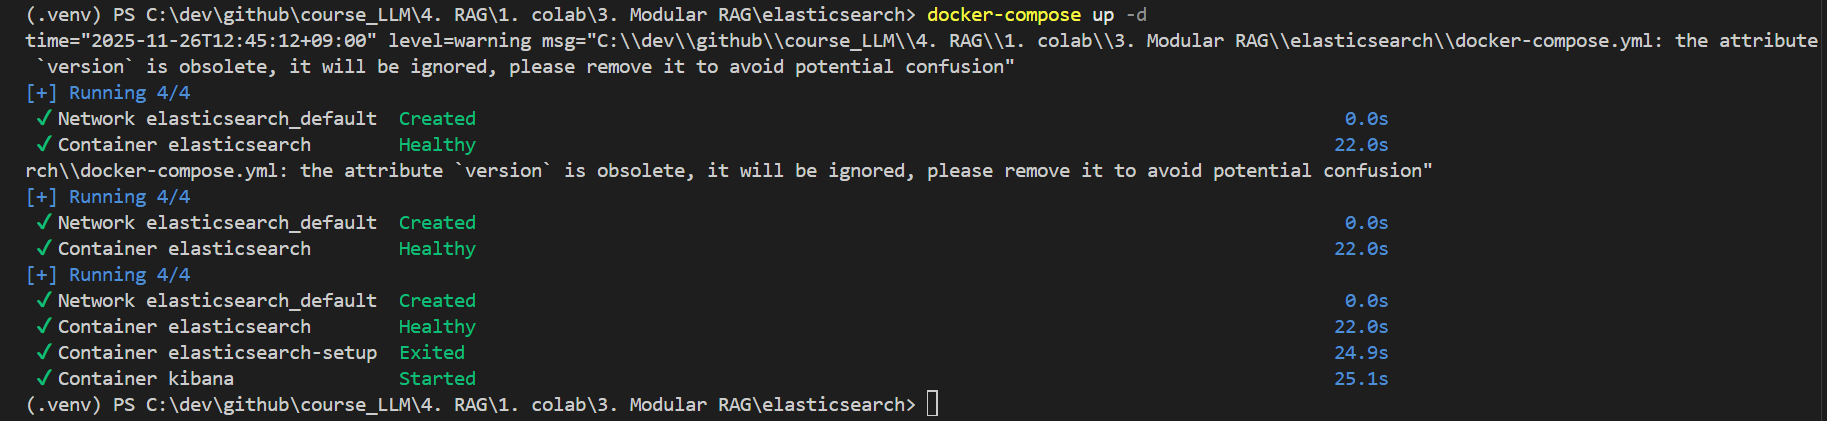

## Elasticsearch 연결 확인

In [1]:
from elasticsearch import Elasticsearch
import warnings

# SSL 경고 무시 (개발 환경용)
warnings.filterwarnings('ignore')

# Elasticsearch 클라이언트 생성
# elasticsearch 9.x는 명시적인 scheme 지정이 필요합니다
try:
    es_client = Elasticsearch(
        ["http://localhost:9200"],  # 리스트 형태로, scheme 포함
        basic_auth=("elastic", "changeme123!"),  # 인증 정보 (보안 활성화 시 필수)
        verify_certs=False,
        ssl_show_warn=False,
        request_timeout=30,
        max_retries=3,
        retry_on_timeout=True,
        # 호환성 헤더 비활성화 (개발 환경용)
        headers={"accept": "application/json", "content-type": "application/json"}
    )
    
    # 연결 확인
    if es_client.ping():
        print("Elasticsearch 연결 성공!")
        print()
        
        # 클러스터 정보
        info = es_client.info()
        print(f"버전: {info['version']['number']}")
        print(f"클러스터 이름: {info['cluster_name']}")
        print(f"노드 이름: {info['name']}")
        print()
        print(f"Elasticsearch URL: http://localhost:9200")
    else:
        print("Elasticsearch 연결 실패 (ping 실패)")
        
except Exception as e:
    print("Elasticsearch 연결 중 오류 발생:")
    print(f"   에러 타입: {type(e).__name__}")
    print(f"   에러 메시지: {str(e)}")

Elasticsearch 연결 성공!

버전: 8.12.1
클러스터 이름: elasticsearch-cluster
노드 이름: elasticsearch-node-1

Elasticsearch URL: http://localhost:9200


## Kibana Web UI
> Kibana를 통해 Elasticsearch를 시각적으로 관리할 수 있습니다.

로그인 정보:
- 로그인 페이지: http://localhost:5601
- Username: elastic
- Password: changeme123!

주요 기능:
- Dev Tools: Elasticsearch API를 직접 테스트
- Discover: 데이터 탐색 및 검색
- Dashboard: 데이터 시각화
- Index Management: 인덱스 관리

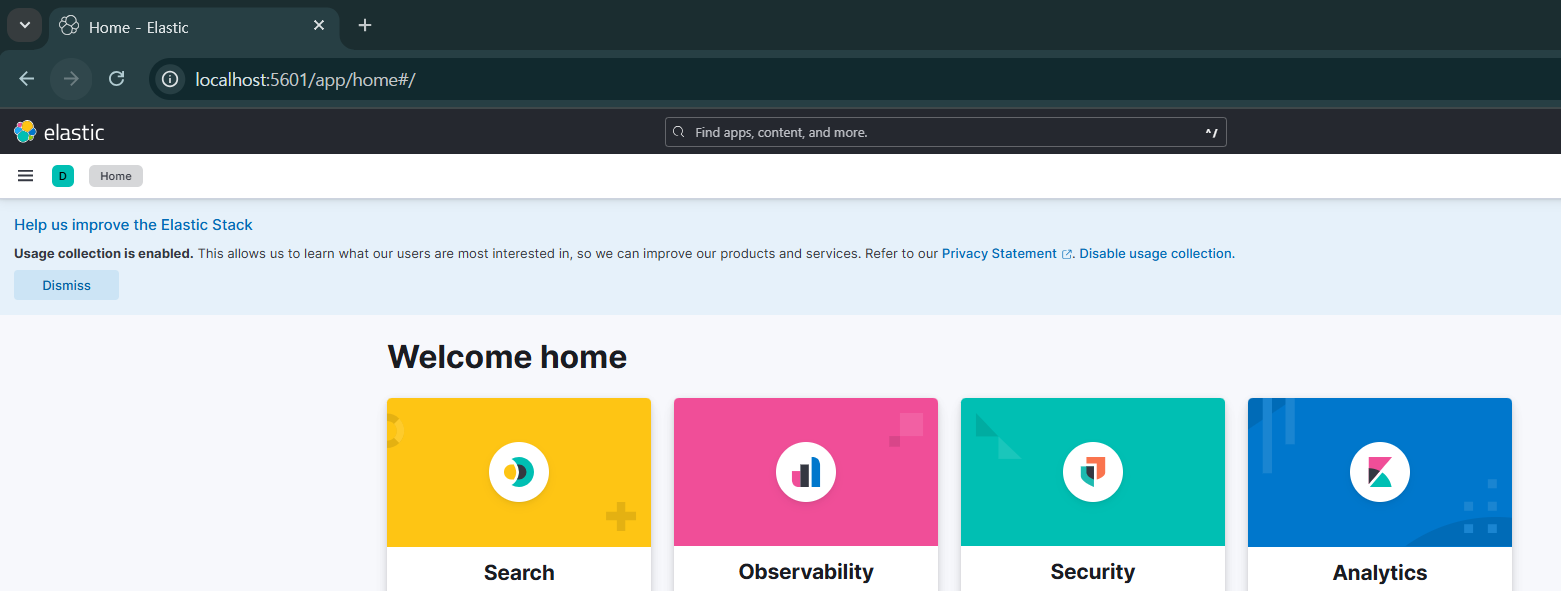

# VectoDB에 데이터 추가하기 

## Loader

In [2]:
from glob import glob

files = glob("./data/*.txt")

print(f"전체 txt 파일의 수: {len(files)}")

전체 txt 파일의 수: 2


In [3]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import TextLoader

loader = DirectoryLoader("./data", glob="*.txt", show_progress=True,
                         loader_cls=TextLoader, loader_kwargs={"encoding": "utf-8"})

docs = loader.load()
print(f"로드된 파일의 수: {len(docs)}")

100%|██████████| 2/2 [00:00<00:00, 114.08it/s]

로드된 파일의 수: 2


## Splitter

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300, chunk_overlap=30)

In [5]:
docs_by_splitter = text_splitter.split_documents(docs)
print(f"분리된 문서의 수: {len(docs_by_splitter)}")

분리된 문서의 수: 65


## Embedding Model

In [6]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

## 벡터 인덱스 생성 

In [7]:
# 인덱스 이름
index_name = "rag_keywords"

# 기존 인덱스 삭제 (있다면)
if es_client.indices.exists(index=index_name):
    es_client.indices.delete(index=index_name)
    print(f"기존 인덱스 '{index_name}' 삭제")

# 벡터 인덱스 매핑 생성 (qwen3-embedding:0.6b는 1024차원)
index_mapping = {
    "mappings": {
        "properties": {
            "text": {
                "type": "text",
                "analyzer": "standard"
            },
            "embedding": {
                "type": "dense_vector",
                "dims": 1024,  # 임베딩 차원 (모델에 따라 조정)
                "index": True,
                "similarity": "cosine"  # 코사인 유사도
            },
            "metadata": {
                "type": "object",
                "enabled": True
            }
        }
    }
}

# 인덱스 생성
es_client.indices.create(index=index_name, body=index_mapping)
print(f"인덱스 '{index_name}' 생성 완료")

인덱스 'rag_keywords' 생성 완료


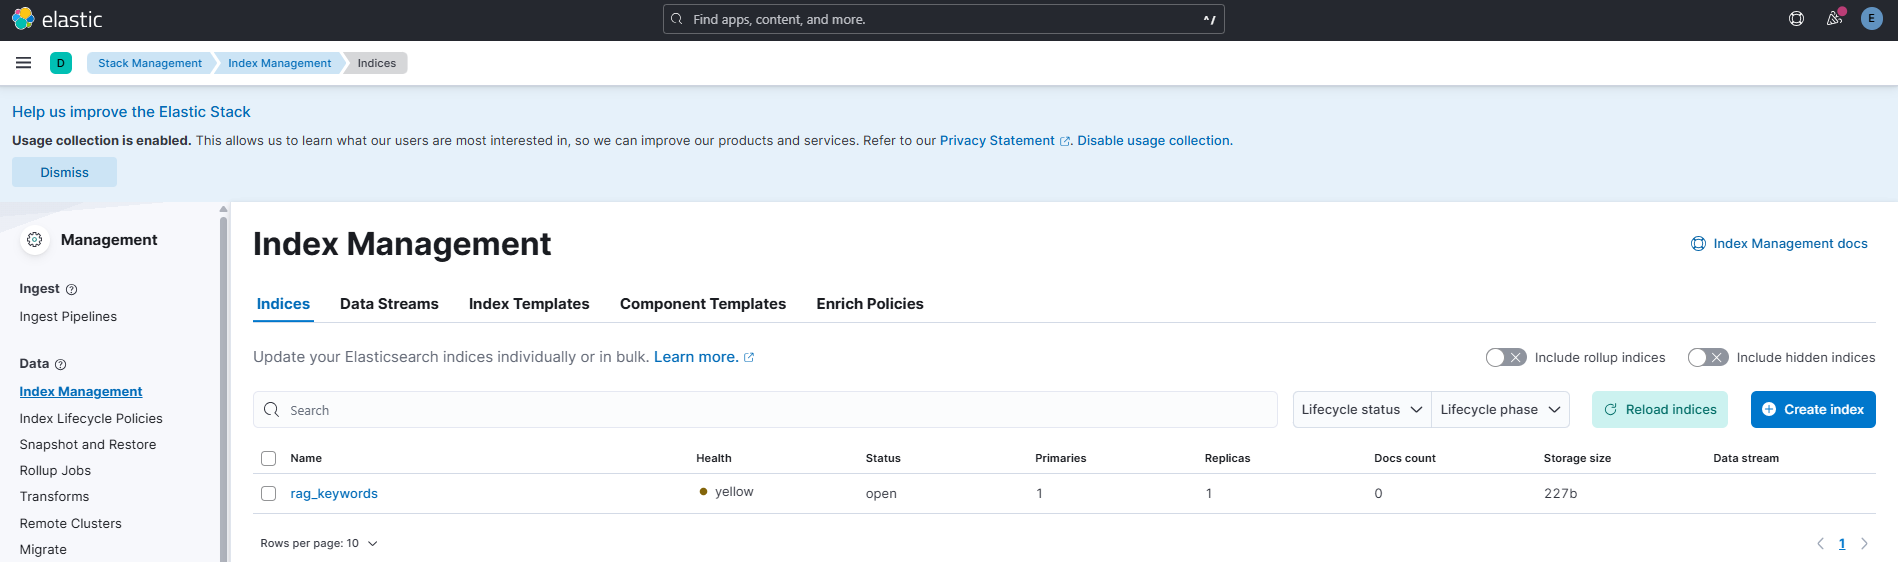

## 데이터 추가하기 

In [8]:
from elasticsearch.helpers import bulk

# 문서 임베딩 생성
texts = [doc.page_content for doc in docs_by_splitter]
embeddings_list = embeddings.embed_documents(texts)

print(f"임베딩 생성 완료: {len(embeddings_list)}개")
print(f"임베딩 차원: {len(embeddings_list[0])}")

# Elasticsearch에 벌크 인덱싱
def generate_docs():
    for i, (doc, embedding) in enumerate(zip(docs_by_splitter, embeddings_list)):
        yield {
            "_index": index_name,
            "_id": i,
            "_source": {
                "text": doc.page_content,
                "embedding": embedding,
                "metadata": doc.metadata
            }
        }

# 벌크 인덱싱 실행
success, failed = bulk(es_client, generate_docs())
print(f"인덱싱 완료: {success}개 성공")

# 인덱스 새로고침 (검색 가능하도록)
es_client.indices.refresh(index=index_name)

# 저장된 문서 수 확인
count = es_client.count(index=index_name)['count']
print(f"저장된 문서 수: {count}개")

임베딩 생성 완료: 65개
임베딩 차원: 1024
인덱싱 완료: 65개 성공
저장된 문서 수: 65개


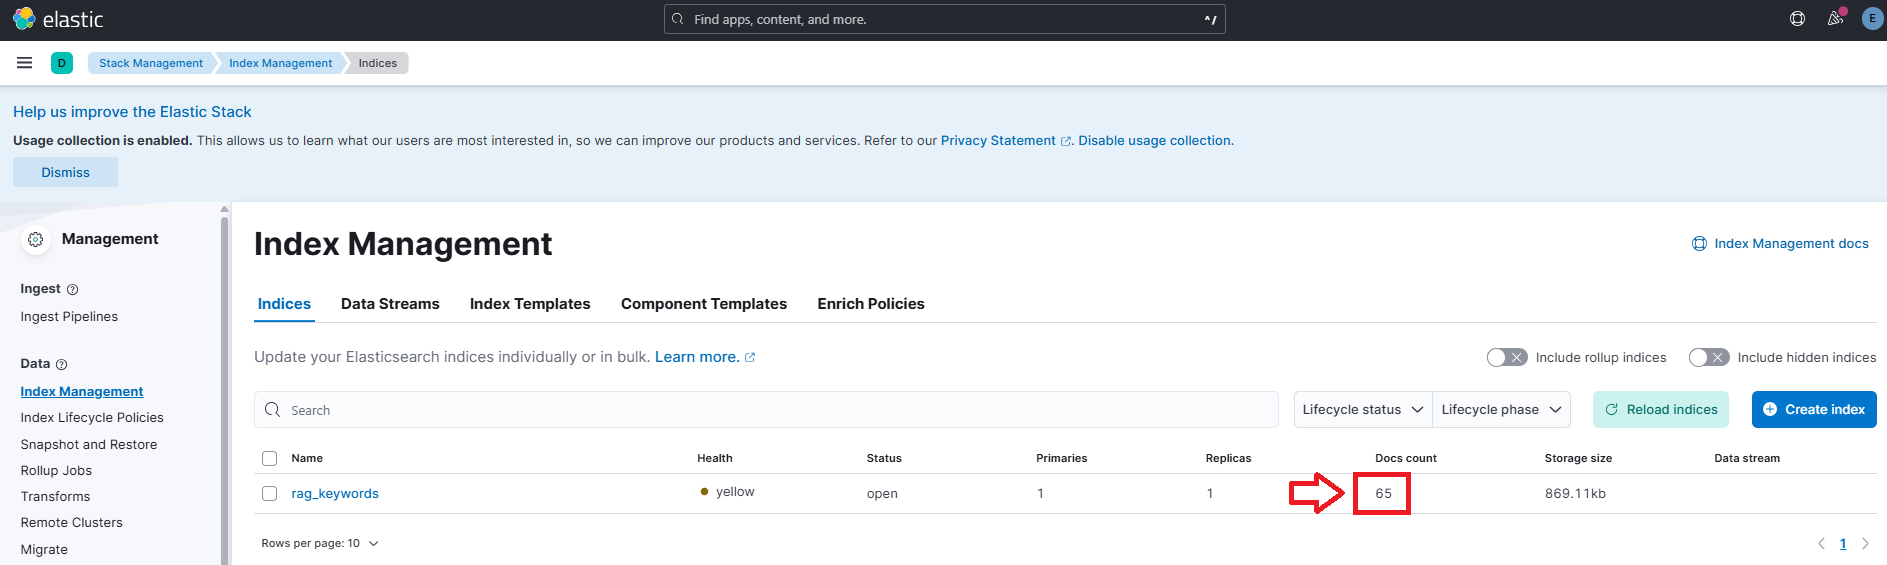

# Elasticsearch Store 구현 

## Singleton Class

In [9]:
from langchain_core.vectorstores.base import VectorStore

class Singleton(type(VectorStore)):
	_instances = {}

	def __call__(cls, *args, **kwargs):
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		return cls._instances[cls]

## ElasticsearchVectorStore Class

In [10]:
from langchain_core.documents import Document
from typing import List, Tuple

class ElasticsearchVectorStore(VectorStore, metaclass=Singleton):
    """Elasticsearch 기반 VectorStore"""

    def __init__(self, es_client, index_name, embeddings, k=2):
        self.es_client = es_client
        self.index_name = index_name
        self._embeddings = embeddings
        self.k = k

    @property
    def embeddings(self):
        """embeddings property getter"""
        return self._embeddings

    @classmethod
    def from_texts(cls,**kwargs):
        """VectorStore 상속을 받기 위한 필수 함수 선언"""
        pass
 

    def __search_similarity(self, query: str, k: int):
        # 쿼리 텍스트를 임베딩으로 변환
        query_embedding = self._embeddings.embed_query(query)
        
        # KNN 검색 쿼리
        search_query = {
            "knn": {
                "field": "embedding",
                "query_vector": query_embedding,
                "k": k,
                "num_candidates": 100  # 후보 문서 수
            },
            "_source": ["text", "metadata"]  # 반환할 필드
        }
        
        # 검색 실행
        return es_client.search(index=index_name, body=search_query)


    def similarity_search(self, query: str, k: int = 4) -> List[Document]:
        """벡터 유사도 검색 함수"""
        
        # 검색 실행
        response = self.__search_similarity(query, k)
        
        # 결과 파싱
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],
                metadata=hit['_source'].get('metadata', {})
            )
            documents.append(doc)

        return documents
    

    def similarity_search_with_score(
        self, query: str, k: int = 4
    ) -> List[Tuple[Document, float]]:
        """쿼리와 유사도 점수를 함께 반환"""

        # 검색 실행
        response = self.__search_similarity(query, k)
        
        # 결과 파싱
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],
                metadata=hit['_source'].get('metadata', {})
            )
            documents.append((doc, hit['_score']))

        return documents
    

    def __search_hybrid(self, query: str, k: int):
        # 쿼리 임베딩
        query_embedding = self._embeddings.embed_query(query)
        
        # 하이브리드 검색 쿼리
        search_query = {
            "query": {
                "bool": {
                    "should": [
                        # BM25 키워드 검색
                        {
                            "match": {
                                "text": {
                                    "query": query,
                                    "boost": 1.0  # 키워드 가중치
                                }
                            }
                        }
                    ]
                }
            },
            "knn": {
                "field": "embedding",
                "query_vector": query_embedding,
                "k": k,
                "num_candidates": 100,
                "boost": 2.0  # 벡터 검색 가중치 (벡터에 더 높은 가중치)
            },
            "size": k,
            "_source": ["text", "metadata"]
        }
    
        # 검색 실행
        return es_client.search(index=index_name, body=search_query)
    

    def hybrid_search(
        self, query: str, k: int = 4
    ) -> List[Document]:
        """하이브리드 검색: 벡터 검색 + BM25 키워드 검색 반환"""

        # 검색 실행
        response = self.__search_hybrid(query, k)
        
        # 결과 파싱
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],
                metadata=hit['_source'].get('metadata', {})
            )
            documents.append(doc)

        return documents    
    

## vectorsotre 테스트 

In [11]:
vectorstore = ElasticsearchVectorStore(
    es_client=es_client,
    index_name=index_name,
    embeddings=embeddings,
    k=2
)

print("Elasticsearch vectorstore 생성 완료")

Elasticsearch vectorstore 생성 완료


In [12]:
rag_result =  vectorstore.similarity_search("Embedding이란?", k=3)

for result in rag_result:
    print("="*50)
    print(f"출처: {result.metadata['source']} / 내용: {result.page_content[:50]}..")

출처: data\rag-keywords.txt / 내용: Embedding

정의: 임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡..
출처: data\rag-keywords.txt / 내용: Semantic Search

정의: 의미론적 검색은 사용자의 질의를 단순한 키워드 매칭을..
출처: data\rag-keywords.txt / 내용: Tokenizer

정의: 토크나이저는 텍스트 데이터를 토큰으로 분할하는 도구입니다. 이는..


## retriever 테스트 

In [13]:
# 벡터스토어를 검색 가능한 형태로 변환
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}  # 상위 3개 문서 반환
)

print("검색기(Retriever)가 설정되었습니다.")

검색기(Retriever)가 설정되었습니다.


In [14]:
web_result = retriever.invoke("HTML란?")

for result in web_result:
    print("="*50)
    print(f"출처: {result.metadata['source']} / 내용: {result.page_content[:50]}..")

출처: data\web-keywords.txt / 내용: HTML (HyperText Markup Language)

정의: HTML은 웹 페이지의..
출처: data\web-keywords.txt / 내용: DOM (Document Object Model)

정의: DOM은 HTML 문서의 구조를..
출처: data\web-keywords.txt / 내용: 정의: HTTP는 웹에서 데이터를 전송하기 위한 프로토콜입니다. 클라이언트와 서버 간의 요..
